# Theoretical Explanation

For two coherent waves reaching a point on the screen, the phase difference is

$$
\phi = \frac{2\pi}{\lambda}\,\Delta,
$$

where $\lambda$ is the wavelength and $\Delta$ is the path difference.

For a screen at distance $D$ and slit separation $d$, the path difference at transverse position $x$ is approximated by

$$
\Delta \approx \frac{dx}{D}.
$$

Hence the phase difference becomes

$$
\phi(x) = \frac{2\pi d x}{\lambda D}.
$$

The corresponding interference intensity for two equal-amplitude waves is

$$
I(x) = 4I_0\cos^2\left(\frac{\phi(x)}{2}\right).
$$

In this notebook, the implemented form is

$$
I = 4\cos^2\left(\frac{\phi}{2}\right),
$$

followed by normalization:

$$
I_{\text{norm}} = \frac{I}{I_{\max}}.
$$

For white light, multiple wavelengths are superposed:

$$
\lambda \in [400,700]\ \text{nm}.
$$

Each wavelength contributes its own colour and intensity pattern, so the total RGB image is formed as

$$
\mathrm{RGB}_{\text{total}}(x,y) = \sum_{\lambda} I_{\text{norm}}(x,\lambda)\,\mathrm{RGB}(\lambda).
$$

Thus, the central region is brightest, and coloured fringes appear because the phase term depends on $\lambda$.


In [7]:
import numpy as np
import colour

def wavelength_to_rgb(lam_nm):
    
    # Outside visible range
    if lam_nm < 380 or lam_nm > 780:
        return np.array([0.0, 0.0, 0.0])
    
    # Convert wavelength → XYZ
    XYZ = colour.wavelength_to_XYZ(lam_nm)
    
    # XYZ → sRGB
    rgb = colour.XYZ_to_sRGB(XYZ)
    
    # Clip invalid values
    rgb = np.clip(rgb, 0, 1)
    
    return rgb




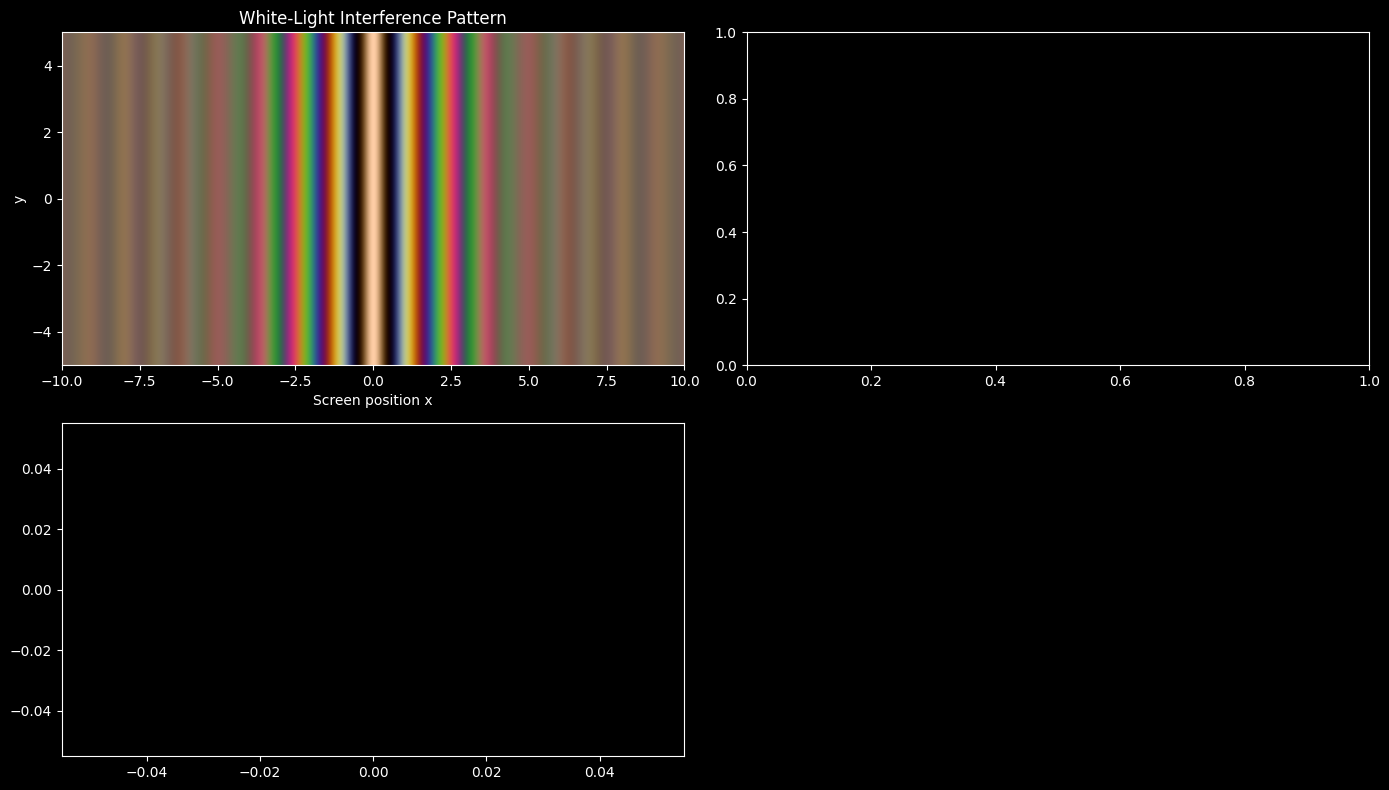

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")
x=np.linspace(-10,10,20000)
y=np.linspace(-5,5,100)

X,Y=np.meshgrid(x,y)

global d
global D


D=100
d=5e-5


whitel=np.linspace(400,700,100)

RGB_total = np.zeros((len(y), len(x), 3))
for n in whitel:
    λ=n*1e-9

    φ=((d*2*np.pi)/(λ*D))*X

    I=4*((np.cos(φ/2))**2)

    # Normalize intensity (VERY IMPORTANT)
    I = I / I.max()

    # Your chosen base colour (example: blue)
    rgb = wavelength_to_rgb(n)   # custom colour
      
    # Create RGB image
    RGB_total += I[:, :, None] * rgb
    


# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax = axes[0, 0]
ax1 = axes[1,0]

RGB_total /= RGB_total.max()
ax.imshow(RGB_total, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', aspect='auto')
ax1.plot()

ax.set_xlabel("Screen position x")
ax.set_ylabel("y")
ax.set_title("White-Light Interference Pattern")

axes[0, 1].axis("on")
axes[1, 0].axis("on")
axes[1, 1].axis("off")
plt.tight_layout()
plt.savefig("YDSE.pdf", bbox_inches="tight", dpi=300)



# Its a test cell

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("dark_background")
x=np.linspace(-10,10,20000)
y=np.linspace(-5,5,100)

X,Y=np.meshgrid(x,y)

global d
global D


D=100
d=5e-5

def YDSE():
    λ=n*1e-9

    φ=((d*2*np.pi)/(λ*D))*X

    I=4*((np.cos(φ/2))**2)

    # Normalize intensity (VERY IMPORTANT)
    I = I / I.max()

    # Your chosen base colour (example: blue)
    rgb = wavelength_to_rgb(n)   # custom colour
    
    return rgb



whitel=np.linspace(400,700,100)

RGB_total = np.zeros((len(y), len(x), 3))
for n in whitel:
    λ=n*1e-9

    φ=((d*2*np.pi)/(λ*D))*X

    I=4*((np.cos(φ/2))**2)

    # Normalize intensity (VERY IMPORTANT)
    I = I / I.max()

    # Your chosen base colour (example: blue)
    rgb = wavelength_to_rgb(n)   # custom colour
      
    # Create RGB image
    RGB_total += I[:, :, None] * rgb
    


# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax = axes[0, 0]
ax1 = axes[1,0]

RGB_total /= RGB_total.max()
ax.imshow(RGB_total, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', aspect='auto')
ax1.plot()

ax.set_xlabel("Screen position x")
ax.set_ylabel("y")
ax.set_title("White-Light Interference Pattern")

axes[0, 1].axis("on")
axes[1, 0].axis("on")
axes[1, 1].axis("off")
plt.tight_layout()
plt.savefig("YDSE.pdf", bbox_inches="tight", dpi=300)

